<a href="https://colab.research.google.com/github/TanviVasagadekar/-Stock-Market-Analysis-Prediction/blob/main/MLminiproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance scikit-learn matplotlib pandas numpy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

In [ ]:
stocks = ["RELIANCE.NS", "TCS.NS", "INFY.NS"]

for i, s in enumerate(stocks):
    print(f"{i}: {s}")

choice = int(input("Select stock number: "))
stock = stocks[choice]

import yfinance as yf
data = yf.download(stock, start="2020-01-01", end="2024-01-01")
data.reset_index(inplace=True)

data.columns = data.columns.get_level_values(0)

data.head()

0: RELIANCE.NS
1: TCS.NS
2: INFY.NS
Select stock number: 0


/tmp/ipykernel_959/959828587.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2020-01-01,675.324219,683.152914,673.490123,679.081997,14004468
1,2020-01-02,686.821228,689.348791,676.397899,676.397899,17710316
2,2020-01-03,687.648804,689.661895,681.318729,685.792252,20984698
3,2020-01-06,671.700745,683.510829,670.134994,679.976780,24519177
4,2020-01-07,682.034546,686.463335,677.068889,679.529321,16683622


In [ ]:
data.dropna(inplace=True)

# Create Target (Up/Down)
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)
data.dropna(inplace=True)

data.head()

Price,Date,Close,High,Low,Open,Volume,Target
0,2020-01-01,675.324219,683.152914,673.490123,679.081997,14004468,1
1,2020-01-02,686.821228,689.348791,676.397899,676.397899,17710316,1
2,2020-01-03,687.648804,689.661895,681.318729,685.792252,20984698,0
3,2020-01-06,671.700745,683.510829,670.134994,679.976780,24519177,1
4,2020-01-07,682.034546,686.463335,677.068889,679.529321,16683622,0


In [ ]:
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R² Score:", model.score(X_test, y_test))

R² Score: 0.9968813497309408


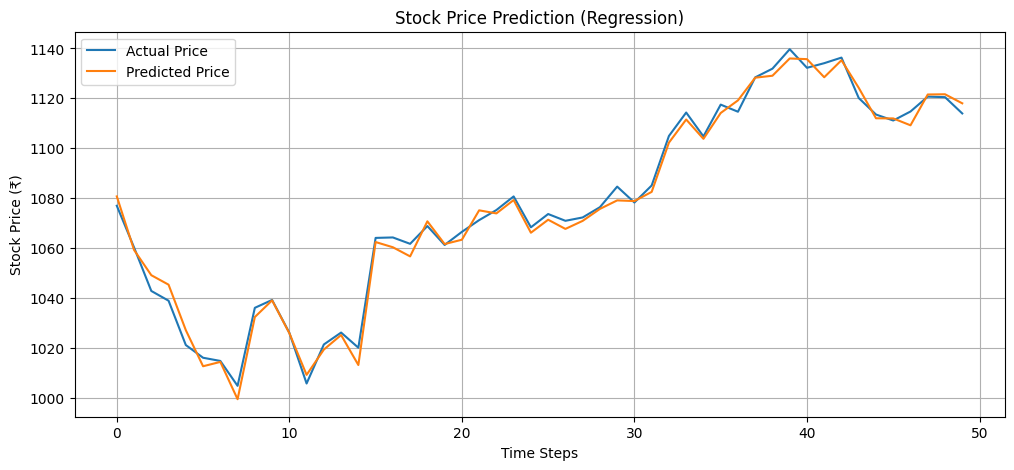

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:50], label="Actual Price")
plt.plot(pred[:50], label="Predicted Price")

plt.xlabel("Time Steps")
plt.ylabel("Stock Price (₹)")
plt.title("Stock Price Prediction (Regression)")

plt.legend(loc="best")
plt.grid(True)

plt.show()

In [ ]:
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

models = {
    "Logistic": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(name, "Accuracy:", acc)

Logistic Accuracy: 0.4623115577889447
KNN Accuracy: 0.49748743718592964
SVM Accuracy: 0.45226130653266333
Decision Tree Accuracy: 0.507537688442211
Random Forest Accuracy: 0.49748743718592964


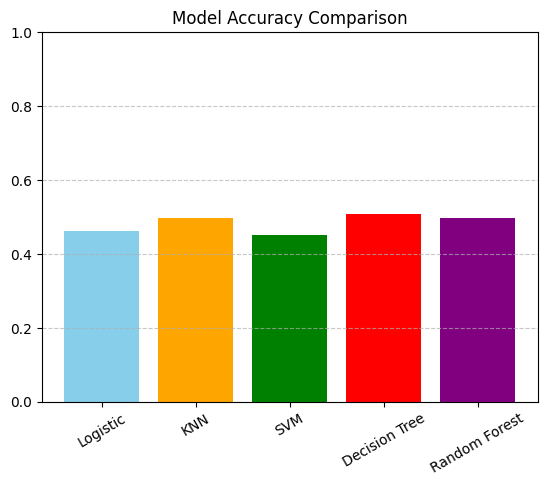

In [ ]:
plt.figure()
colors = ['skyblue', 'orange', 'green', 'red', 'purple']
bars = plt.bar(results.keys(), results.values(), color=colors)
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)  # Accuracy range
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
X_cluster = data[['Close', 'Volume']]

kmeans = KMeans(n_clusters=3)
data['Cluster'] = kmeans.fit_predict(X_cluster)

data[['Close', 'Volume', 'Cluster']].head()

Price,Close,Volume,Cluster
0,675.324219,14004468,0
1,686.821228,17710316,0
2,687.648804,20984698,0
3,671.700745,24519177,0
4,682.034546,16683622,0


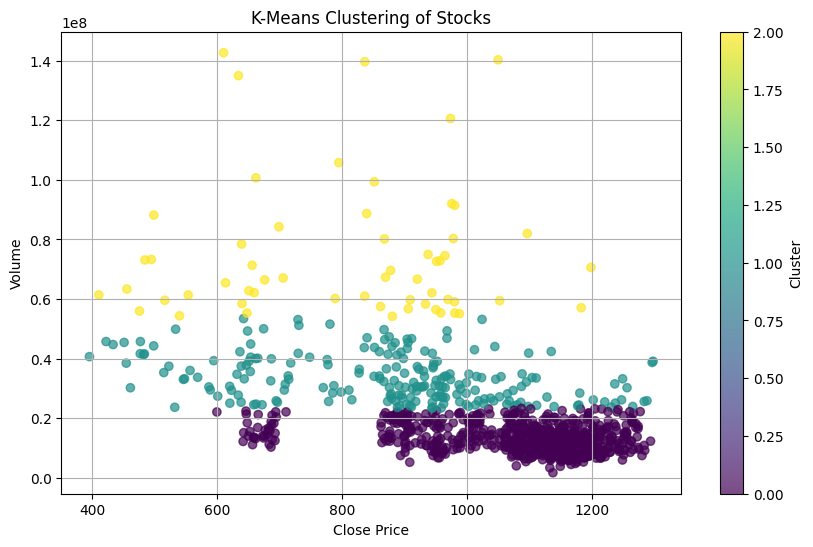

In [ ]:
X_cluster = data[['Close', 'Volume']]

kmeans = KMeans(n_clusters=3)
data['Cluster'] = kmeans.fit_predict(X_cluster)

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    data['Close'],
    data['Volume'],
    c=data['Cluster'],
    cmap='viridis',   # better color scheme
    alpha=0.7
)

plt.xlabel("Close Price")
plt.ylabel("Volume")
plt.title("K-Means Clustering of Stocks")

plt.colorbar(scatter, label="Cluster")  # shows cluster legend
plt.grid(True)

plt.show()

In [ ]:
latest_row = data.tail(1)

print("\n📊 ===== Latest Market Data =====")
print(f"Date        : {latest_row['Date'].values[0]}")
print(f"Close Price : ₹ {latest_row['Close'].values[0]:.2f}")
print(f"High        : ₹ {latest_row['High'].values[0]:.2f}")
print(f"Low         : ₹ {latest_row['Low'].values[0]:.2f}")
print(f"Open        : ₹ {latest_row['Open'].values[0]:.2f}")
print(f"Volume      : {int(latest_row['Volume'].values[0])}")

# Prepare the latest data for prediction using the same features as the classification models
# Ensure feature names are consistent with training data to avoid warnings
latest_features_df = latest_row[['Open', 'High', 'Low', 'Volume']]

# Use one of the trained classification models, for example, RandomForestClassifier
# The 'models' dictionary was created in cell zkgRSlD_hGBh
clf_model = models['Random Forest']

# Get the prediction (0 or 1)
prediction = clf_model.predict(latest_features_df)[0]

# Get the prediction probabilities
prob = clf_model.predict_proba(latest_features_df)[0]

print("\n🤖 ===== MODEL PREDICTION =====")

if prediction == 1:
    print("📈 Recommendation: BUY")
    print(f"Confidence: {prob[1]*100:.2f}%")
    print("Reason: Positive trend and momentum detected.")
else:
    print("📉 Recommendation: SELL")
    print(f"Confidence: {prob[0]*100:.2f}%")
    print("Reason: Weak trend based on recent market patterns.")


📊 ===== Latest Market Data =====
Date        : 2023-12-29T00:00:00.000000000
Close Price : ₹ 1282.98
High        : ₹ 1297.40
Low         : ₹ 1280.17
Open        : ₹ 1295.96
Volume      : 10864584

🤖 ===== MODEL PREDICTION =====
📉 Recommendation: SELL
Confidence: 86.00%
Reason: Weak trend based on recent market patterns.
